In [1]:
import json
from freezeplots import (
    combined,
    complete,
    plot_supercooling,
)


from freezeplots.paths import PROC_DATA_DIR, PLOT_DIR, CHANNEL_LAYOUT_PATH
with CHANNEL_LAYOUT_PATH.open(
    "r",
    encoding="utf-8",
) as file:
    channel_layout = json.load(file)

input_path = PROC_DATA_DIR / "manual_supercooling_events.csv"
output_path = PLOT_DIR / "EJ01A1-4.png"

Loaded 871 channel records from /home/juk/freeze/data/data_processed/manual_supercooling_events.csv
Plot saved to: /home/juk/freeze/output/plots/EJ01A1-4.png


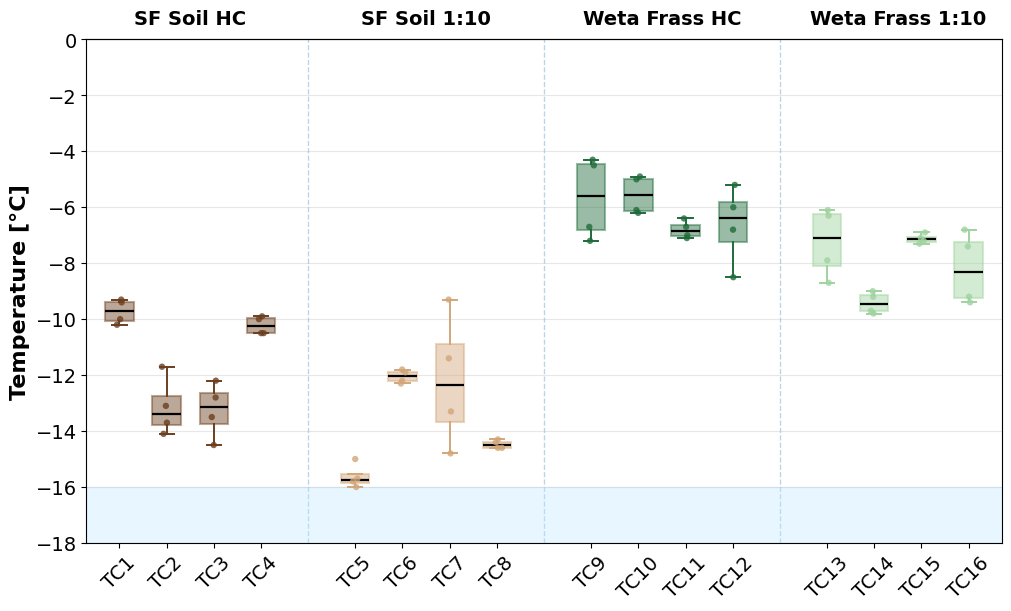

(<Figure size 1000x600 with 1 Axes>, <Axes: ylabel='Temperature [°C]'>)

In [2]:
# ============================================================
# Reproducibility plot for EJ01A1–EJ01A4
# Grouped by shared channel-layout labels
# ============================================================

repeated_experiments = [
    "EJ01A1",
    "EJ01A2",
    "EJ01A3",
    "EJ01A4",
]

reference_experiment = "EJ01A1"


# Colors for the four sample groups
TREATMENT_COLORS = {
    # Soil HC: dark brown
    "TC1": "#6B3E1E",
    "TC2": "#6B3E1E",
    "TC3": "#6B3E1E",
    "TC4": "#6B3E1E",

    # Soil 1:10: light brown
    "TC5": "#D2A679",
    "TC6": "#D2A679",
    "TC7": "#D2A679",
    "TC8": "#D2A679",

    # Weta Frass HC: dark green
    "TC9": "#1F6B3A",
    "TC10": "#1F6B3A",
    "TC11": "#1F6B3A",
    "TC12": "#1F6B3A",

    # Weta Frass 1:10: light green
    "TC13": "#9FD39F",
    "TC14": "#9FD39F",
    "TC15": "#9FD39F",
    "TC16": "#9FD39F",
}

# Define the four TC groups
tc_groups = [
    ["TC1", "TC2", "TC3", "TC4"],
    ["TC5", "TC6", "TC7", "TC8"],
    ["TC9", "TC10", "TC11", "TC12"],
    ["TC13", "TC14", "TC15", "TC16"],
]


# Build plot_sections automatically.
# Each section gets its label from the channel_layout of the
# first TC in that group.
plot_sections = []

for tc_group in tc_groups:
    section_label = channel_layout[
        reference_experiment
    ][tc_group[0]]

    section = {
        "label": section_label,
        "gap_after": 1.0,
        "plots": [],
    }

    for tc in tc_group:
        section["plots"].append(
            combined(
                tc,   # bottom-axis label: only TC name
                {
                    experiment_id: [tc]
                    for experiment_id in repeated_experiments
                },
            )
        )

    plot_sections.append(section)

plot_supercooling(
    figsize = (10, 6),
    y_range=(-18, 0),
    axis_label_size=16,
    group_label_size=14,
    tick_label_size=14,
    x_label_rotation=45,

    plot_sections=plot_sections,
    treatment_colors=TREATMENT_COLORS,
    input_path=input_path,
    output_path=output_path,
    show_legend=False,
    title=None
)